# Diagnostic de Moteurs DC 12V par IA
### Classification Binaire : Normal vs Surcharge

---

## Contexte

> Ce notebook implemente une **classification binaire** : le moteur est-il en
> etat normal ou en surcharge ?
>
> La surcharge est la panne la plus frequente sur un moteur DC 12V et la plus
> dangereuse si elle n'est pas detectee rapidement (echauffement, endommagement
> des enroulements, perte de rendement).

## Formule physique — Score de Surcharge

```
z_I   = (Current     - 10.0) / 3.0    <- ecart au courant nominal
z_T   = (Temperature - 50.0) / 15.0   <- ecart a la temperature nominale
z_Vib = (Vibration   - 100.0) / 25.0  <- ecart a la vibration nominale

ol_score = 0.45 * z_I + 0.35 * z_T + 0.20 * z_Vib

Surcharge  si  ol_score > 0.6
Normal     sinon
```

**Poids physiques :**
- **0.45 x z_I** : le courant est le principal indicateur de surcharge electrique
- **0.35 x z_T** : la temperature trahit l'echauffement progressif
- **0.20 x z_Vib** : les vibrations augmentent sous charge mecanique excessive

## Algorithmes

| # | Algorithme | Gestion desequilibre |
|---|-----------|---------------------|
| 1 | Random Forest | `class_weight='balanced'` |
| 2 | HistGradientBoosting | `class_weight='balanced'` |
| 3 | MLP | Undersample equilibre |
| 4 | KNN (k=5) | Undersample equilibre |
| 5 | SVM RBF | Undersample equilibre |
| 6 | XGBoost | `sample_weight` |
| 7 | Ensemble Soft Voting | Moyenne des probabilites |

---

## 1. Installation des Dependances

In [1]:
import subprocess, sys

packages = ["numpy", "pandas", "scikit-learn",
            "matplotlib", "seaborn", "joblib", "xgboost"]
for pkg in packages:
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", pkg, "-q"],
        capture_output=True
    )
    print(f"  {pkg:<20} {'OK' if result.returncode == 0 else 'ERREUR'}")

print("\nInstallation terminee.")

  numpy                OK
  pandas               OK
  scikit-learn         OK
  matplotlib           OK
  seaborn              OK
  joblib               OK
  xgboost              OK

Installation terminee.


---
## 2. Importation des Librairies

In [2]:
import os, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns
import joblib

%matplotlib inline
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"]  = 10

CLASS_COLORS = {"Normal": "#2ecc71", "Surcharge": "#e67e22"}
print("Librairies importees.")

Librairies importees.


---
## 3. Configuration

In [3]:
# =============================================================
#  CONFIGURATION
# =============================================================

DATA_PATH  = r"dataset1\iot_equipment_monitoring_dataset.csv"
OUTPUT_DIR = "outputs_binary"

# Valeurs nominales moteur DC 12V
I_NOM   = 10.0;  I_STD   = 3.0
T_NOM   = 50.0;  T_STD   = 15.0
VIB_NOM = 100.0; VIB_STD = 25.0

# Seuil de surcharge (reglable)
OL_THRESHOLD = 0.6

# Poids du score de surcharge
W_CURRENT = 0.45
W_TEMP    = 0.35
W_VIB     = 0.20

# Tailles sous-ensembles
MLP_MAX = 5000
KNN_MAX = 5000
SVM_MAX = 3000

# =============================================================

os.makedirs(OUTPUT_DIR, exist_ok=True)
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset introuvable : '{DATA_PATH}'\n"
        "Verifiez le chemin dans la cellule de configuration."
    )
print(f"Dataset     : {DATA_PATH}")
print(f"Sorties     : {OUTPUT_DIR}/")
print(f"Seuil OL    : {OL_THRESHOLD}")
print(f"Poids score : {W_CURRENT}*z_I + {W_TEMP}*z_T + {W_VIB}*z_Vib")

Dataset     : dataset1\iot_equipment_monitoring_dataset.csv
Sorties     : outputs_binary/
Seuil OL    : 0.6
Poids score : 0.45*z_I + 0.35*z_T + 0.2*z_Vib


---
## 4. Chargement du Dataset

In [4]:
df_raw = pd.read_csv(DATA_PATH)
print(f"Shape : {df_raw.shape[0]:,} lignes x {df_raw.shape[1]} colonnes")
df_raw.head(5)

Shape : 50,000 lignes x 17 colonnes


,Timestamp,Sensor_ID,Temperature,Vibration,Pressure,Voltage,Current,FFT_Feature1,FFT_Feature2,Normalized_Temp,Normalized_Vibration,Normalized_Pressure,Normalized_Voltage,Normalized_Current,Anomaly_Score,Fault_Type,Fault_Status
0,2015-01-01 00:00:00,S151,47.698252,34.225292,176.199516,241.587771,8.323269,0.224737,0.093476,0.524226,0.211423,0.397119,0.800961,0.446526,0.239856,NaN,0
1,2015-01-01 00:01:00,S192,67.260549,134.072771,110.942636,235.003165,11.072823,0.973402,0.628513,0.682771,0.672347,0.240942,0.720230,0.552688,0.776081,NaN,0
2,2015-01-01 00:02:00,S114,45.056722,70.595452,246.739554,232.244324,10.353556,0.566625,0.417355,0.502817,0.379318,0.565941,0.686405,0.524917,0.039005,NaN,0
3,2015-01-01 00:03:00,S171,40.260670,98.252385,202.632051,225.922517,10.228006,0.872516,0.926135,0.463947,0.506990,0.460380,0.608896,0.520069,0.584953,NaN,0
4,2015-01-01 00:04:00,S160,56.311983,138.959633,231.149735,198.928891,18.878552,0.876380,0.174530,0.594037,0.694906,0.528630,0.277939,0.854070,0.944961,NaN,0


---
## 5. Construction du Label Binaire par Formule Physique

### Modele physique de la surcharge

Un moteur DC en surcharge presente simultanement :
- Un **courant plus eleve** que nominal (motor force de tourner sous charge excessive)
- Une **temperature en hausse** (dissipation thermique de la puissance perdue)
- Des **vibrations accrues** (contraintes mecaniques sur l'arbre et les roulements)

Le score de surcharge combine ces 3 indicateurs de maniere ponderee :

```
ol_score = 0.45 * (I - I_nom)/sigma_I
         + 0.35 * (T - T_nom)/sigma_T
         + 0.20 * (Vib - Vib_nom)/sigma_Vib
```

Si `ol_score > 0.6` -> **Surcharge**, sinon -> **Normal**

In [5]:
df = df_raw.copy()

# Z-scores (ecarts normalises aux valeurs nominales)
df["z_I"]   = (df["Current"]     - I_NOM)   / I_STD
df["z_T"]   = (df["Temperature"] - T_NOM)   / T_STD
df["z_Vib"] = (df["Vibration"]   - VIB_NOM) / VIB_STD

# Score de surcharge
df["ol_score"] = (W_CURRENT * df["z_I"] +
                  W_TEMP    * df["z_T"] +
                  W_VIB     * df["z_Vib"])

# Label binaire
df["Label"] = df["ol_score"].apply(
    lambda s: "Surcharge" if s > OL_THRESHOLD else "Normal"
)

assert df["Label"].isnull().sum() == 0

print("Distribution des classes (labels physiques) :")
vc = df["Label"].value_counts()
for cls, cnt in vc.items():
    pct = cnt / len(df) * 100
    bar = "#" * int(pct / 2)
    print(f"  {cls:<12} : {cnt:>6,}  ({pct:.1f}%)  {bar}")

print(f"\nol_score min  : {df['ol_score'].min():.4f}")
print(f"ol_score max  : {df['ol_score'].max():.4f}")
print(f"ol_score mean : {df['ol_score'].mean():.4f}")
print(f"ol_score std  : {df['ol_score'].std():.4f}")

Distribution des classes (labels physiques) :
  Normal       : 41,978  (84.0%)  #########################################
  Surcharge    :  8,022  (16.0%)  ########

ol_score min  : -2.9988
ol_score max  : 2.3737
ol_score mean : -0.0008
ol_score std  : 0.6047


---
## 6. Visualisation de la Separation des Classes

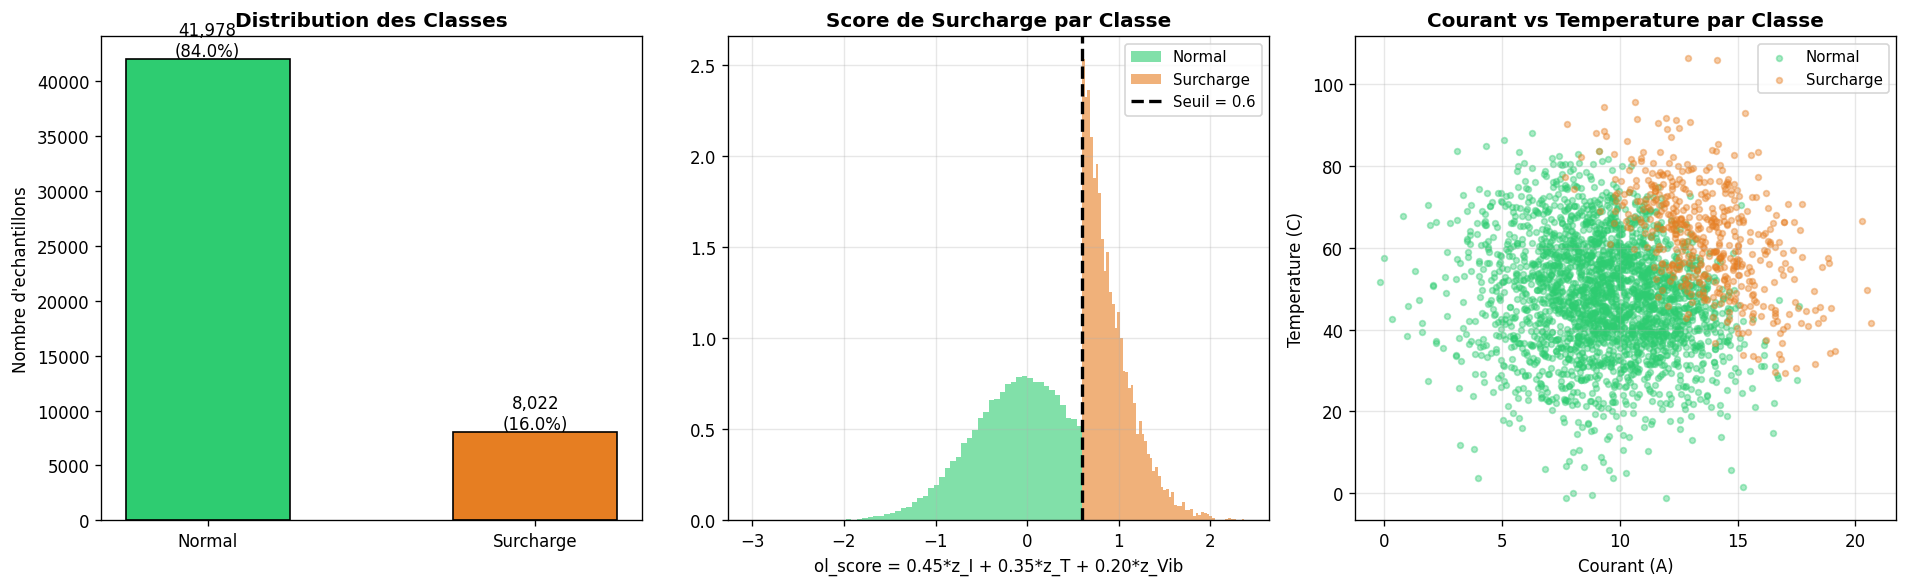

Figure sauvegardee : outputs_binary/distribution_binary.png


In [6]:
vc = df["Label"].value_counts()
cls_order = ["Normal", "Surcharge"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribution
axes[0].bar(cls_order, [vc[c] for c in cls_order],
            color=[CLASS_COLORS[c] for c in cls_order],
            edgecolor="black", width=0.5)
axes[0].set_title("Distribution des Classes", fontweight="bold")
axes[0].set_ylabel("Nombre d'echantillons")
for i, cls in enumerate(cls_order):
    axes[0].text(i, vc[cls]+300, f"{vc[cls]:,}\n({vc[cls]/len(df)*100:.1f}%)",
                 ha="center", fontsize=10)

# Histogramme du score OL
for cls in cls_order:
    vals = df[df["Label"]==cls]["ol_score"].values
    axes[1].hist(vals, bins=60, alpha=0.6,
                 label=cls, color=CLASS_COLORS[cls], density=True)
axes[1].axvline(OL_THRESHOLD, color="black", linestyle="--",
                linewidth=2, label=f"Seuil = {OL_THRESHOLD}")
axes[1].set_title("Score de Surcharge par Classe", fontweight="bold")
axes[1].set_xlabel("ol_score = 0.45*z_I + 0.35*z_T + 0.20*z_Vib")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

# Scatter Current vs Temperature
sample = df.sample(3000, random_state=42)
for cls in cls_order:
    sub = sample[sample["Label"]==cls]
    axes[2].scatter(sub["Current"], sub["Temperature"],
                    c=CLASS_COLORS[cls], alpha=0.4, s=12, label=cls)
axes[2].set_xlabel("Courant (A)")
axes[2].set_ylabel("Temperature (C)")
axes[2].set_title("Courant vs Temperature par Classe", fontweight="bold")
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "distribution_binary.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/distribution_binary.png")

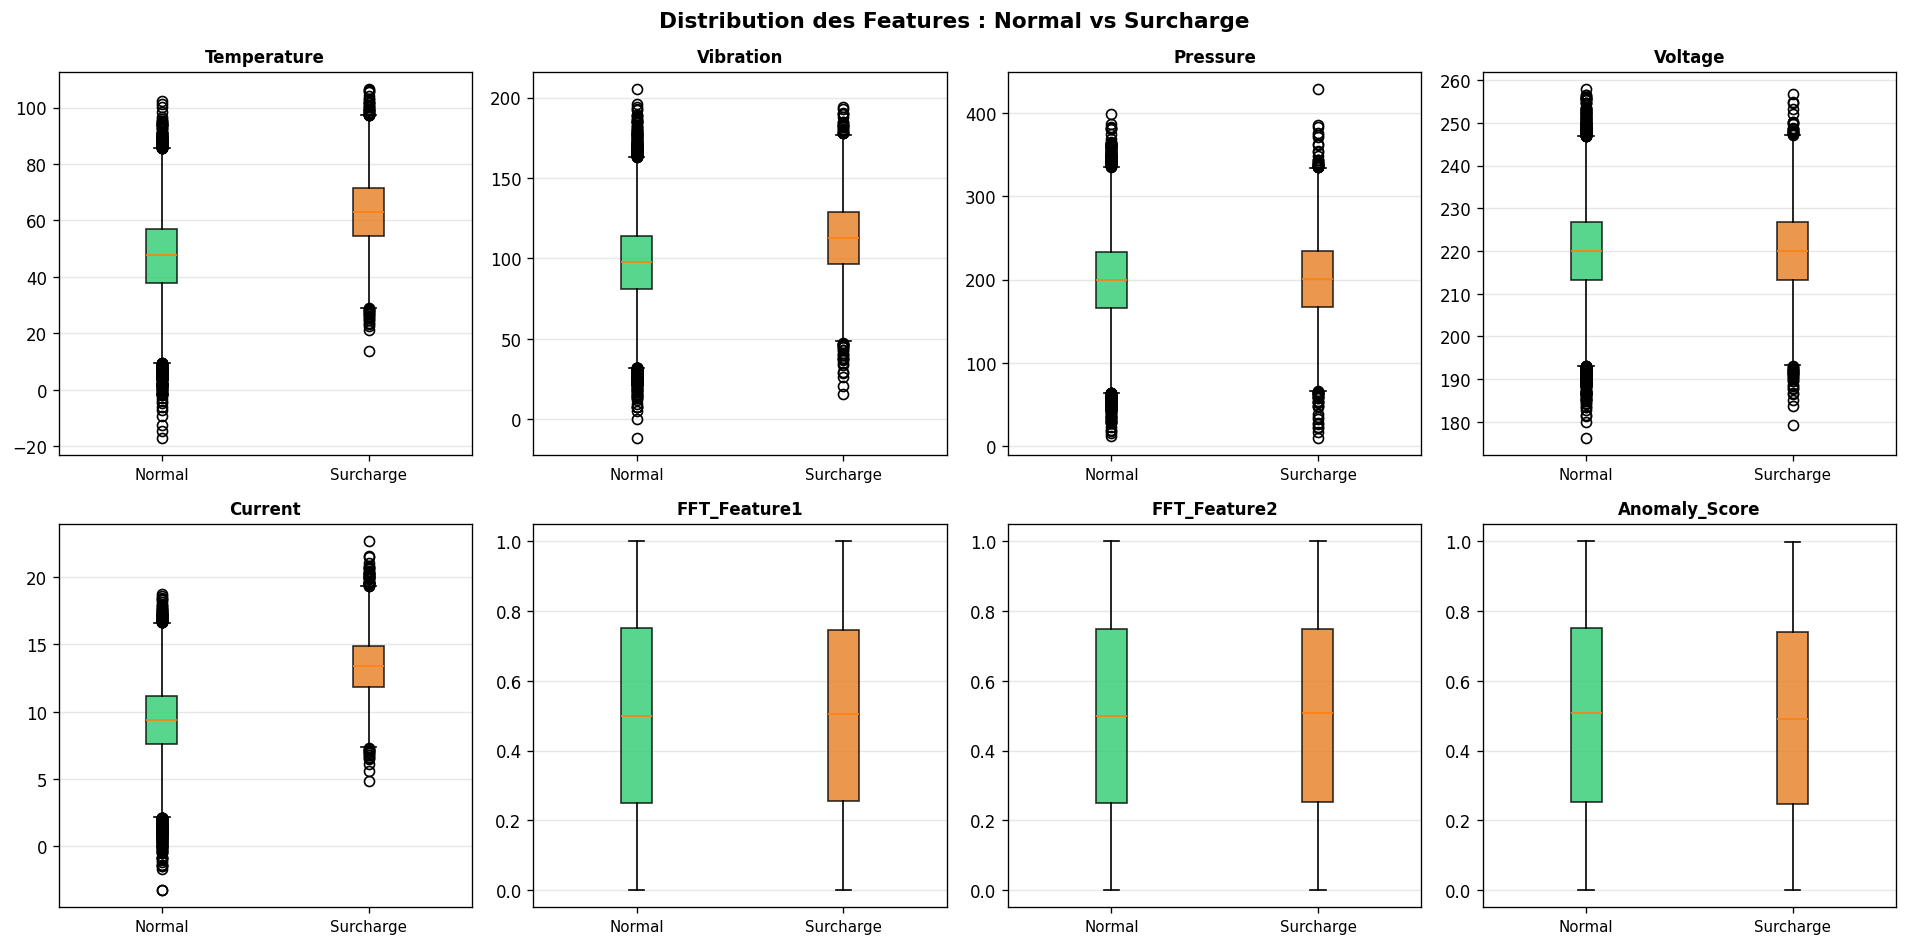

Figure sauvegardee : outputs_binary/feature_boxplots.png


In [7]:
# Boxplots des features par classe
FEATURE_COLS = [
    "Temperature", "Vibration", "Pressure",
    "Voltage", "Current",
    "FFT_Feature1", "FFT_Feature2", "Anomaly_Score"
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, feat in zip(axes, FEATURE_COLS):
    data = [df[df["Label"]==cls][feat].values for cls in cls_order]
    bp = ax.boxplot(data, patch_artist=True, labels=cls_order)
    for patch, cls in zip(bp["boxes"], cls_order):
        patch.set_facecolor(CLASS_COLORS[cls])
        patch.set_alpha(0.8)
    ax.set_title(feat, fontweight="bold", fontsize=10)
    ax.tick_params(axis="x", labelsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Distribution des Features : Normal vs Surcharge",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "feature_boxplots.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/feature_boxplots.png")

---
## 7. Features et Encodage

In [8]:
# 8 features physiques (sans Normalized_* : correlation=1.0 avec originaux)
FEATURE_COLS = [
    "Temperature", "Vibration", "Pressure",
    "Voltage", "Current",
    "FFT_Feature1", "FFT_Feature2", "Anomaly_Score"
]

X     = np.nan_to_num(df[FEATURE_COLS].values.astype(float),
                      nan=0.0, posinf=0.0, neginf=0.0)
le    = LabelEncoder()
y_enc = le.fit_transform(df["Label"].values)
CLASS_NAMES = [str(c) for c in le.classes_]

# Identifier l'index de "Surcharge" pour les metriques ROC
SURCHARGE_IDX = list(CLASS_NAMES).index("Surcharge")

print(f"Features ({len(FEATURE_COLS)}) : {FEATURE_COLS}")
print(f"\nClasses encodees :")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  {i}  ->  {cls:<12} ({np.sum(y_enc==i):,} echantillons)")
print(f"\nIndex classe positive (Surcharge) : {SURCHARGE_IDX}")

Features (8) : ['Temperature', 'Vibration', 'Pressure', 'Voltage', 'Current', 'FFT_Feature1', 'FFT_Feature2', 'Anomaly_Score']

Classes encodees :
  0  ->  Normal       (41,978 echantillons)
  1  ->  Surcharge    (8,022 echantillons)

Index classe positive (Surcharge) : 1


---
## 8. Split Train/Test et Normalisation

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, stratify=y_enc, random_state=42
)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train : {X_train_s.shape[0]:,}  |  Test : {X_test_s.shape[0]:,}")
print(f"Test distribution : {dict(zip(CLASS_NAMES, np.bincount(y_test)))}")

# Undersample equilibre pour MLP, KNN, SVM
def balanced_subsample(X, y, max_per_class, seed=42):
    rng = np.random.RandomState(seed)
    idx = []
    for c in np.unique(y):
        ci     = np.where(y == c)[0]
        n      = min(len(ci), max_per_class)
        chosen = rng.choice(ci, n, replace=False)
        idx.extend(chosen)
    idx = np.array(idx)
    rng.shuffle(idx)
    return X[idx], y[idx]

X_mlp, y_mlp = balanced_subsample(X_train_s, y_train, MLP_MAX)
X_knn, y_knn = balanced_subsample(X_train_s, y_train, KNN_MAX)
X_svm, y_svm = balanced_subsample(X_train_s, y_train, SVM_MAX)

# Poids pour XGBoost
counts   = np.bincount(y_train)
sw_xgb   = np.array([len(y_train) / (len(counts) * counts[c]) for c in y_train])

print(f"\nSous-ensemble MLP : {len(y_mlp):,}  dist={np.bincount(y_mlp)}")
print(f"Sous-ensemble KNN : {len(y_knn):,}  dist={np.bincount(y_knn)}")
print(f"Sous-ensemble SVM : {len(y_svm):,}  dist={np.bincount(y_svm)}")

Train : 40,000  |  Test : 10,000
Test distribution : {'Normal': np.int64(8396), 'Surcharge': np.int64(1604)}

Sous-ensemble MLP : 10,000  dist=[5000 5000]
Sous-ensemble KNN : 10,000  dist=[5000 5000]
Sous-ensemble SVM : 6,000  dist=[3000 3000]


---
## 9. Modele 1 — Random Forest

In [10]:
t0 = time.time()
rf = RandomForestClassifier(
    n_estimators=300,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_s, y_train)
y_pred_rf   = rf.predict(X_test_s)
proba_rf    = rf.predict_proba(X_test_s)
t_rf        = time.time() - t0

auc_rf = roc_auc_score(y_test, proba_rf[:, SURCHARGE_IDX])
print(f"Temps    : {t_rf:.1f}s")
print(f"Accuracy : {accuracy_score(y_test,y_pred_rf)*100:.2f}%")
print(f"F1 binar : {f1_score(y_test,y_pred_rf,average='binary',pos_label=SURCHARGE_IDX,zero_division=0)*100:.2f}%")
print(f"AUC-ROC  : {auc_rf:.4f}")
print()
print(classification_report(y_test,y_pred_rf,target_names=CLASS_NAMES,zero_division=0))

Temps    : 5.4s
Accuracy : 98.62%
F1 binar : 95.60%
AUC-ROC  : 0.9989

              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99      8396
   Surcharge       0.98      0.93      0.96      1604

    accuracy                           0.99     10000
   macro avg       0.98      0.97      0.97     10000
weighted avg       0.99      0.99      0.99     10000



---
## 10. Modele 2 — HistGradientBoosting

In [11]:
t0 = time.time()
hgb = HistGradientBoostingClassifier(
    max_iter=200,
    max_depth=6,
    learning_rate=0.1,
    min_samples_leaf=30,
    class_weight="balanced",
    random_state=42
)
hgb.fit(X_train_s, y_train)
y_pred_hgb  = hgb.predict(X_test_s)
proba_hgb   = hgb.predict_proba(X_test_s)
t_hgb       = time.time() - t0

auc_hgb = roc_auc_score(y_test, proba_hgb[:, SURCHARGE_IDX])
print(f"Temps    : {t_hgb:.1f}s")
print(f"Accuracy : {accuracy_score(y_test,y_pred_hgb)*100:.2f}%")
print(f"F1 binar : {f1_score(y_test,y_pred_hgb,average='binary',pos_label=SURCHARGE_IDX,zero_division=0)*100:.2f}%")
print(f"AUC-ROC  : {auc_hgb:.4f}")
print()
print(classification_report(y_test,y_pred_hgb,target_names=CLASS_NAMES,zero_division=0))

Temps    : 3.7s
Accuracy : 98.87%
F1 binar : 96.55%
AUC-ROC  : 0.9995

              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99      8396
   Surcharge       0.95      0.99      0.97      1604

    accuracy                           0.99     10000
   macro avg       0.97      0.99      0.98     10000
weighted avg       0.99      0.99      0.99     10000



---
## 11. Modele 3 — MLP

Architecture : `Input(8)` → **64** → **32** → `Output(2)`

In [12]:
t0 = time.time()
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    alpha=0.001,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=42,
    verbose=False
)
mlp.fit(X_mlp, y_mlp)
y_pred_mlp  = mlp.predict(X_test_s)
proba_mlp   = mlp.predict_proba(X_test_s)
t_mlp       = time.time() - t0

auc_mlp = roc_auc_score(y_test, proba_mlp[:, SURCHARGE_IDX])
print(f"Temps    : {t_mlp:.1f}s  (iterations : {mlp.n_iter_})")
print(f"Accuracy : {accuracy_score(y_test,y_pred_mlp)*100:.2f}%")
print(f"F1 binar : {f1_score(y_test,y_pred_mlp,average='binary',pos_label=SURCHARGE_IDX,zero_division=0)*100:.2f}%")
print(f"AUC-ROC  : {auc_mlp:.4f}")
print()
print(classification_report(y_test,y_pred_mlp,target_names=CLASS_NAMES,zero_division=0))

Temps    : 1.7s  (iterations : 43)
Accuracy : 99.07%
F1 binar : 97.17%
AUC-ROC  : 0.9998

              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99      8396
   Surcharge       0.95      0.99      0.97      1604

    accuracy                           0.99     10000
   macro avg       0.97      0.99      0.98     10000
weighted avg       0.99      0.99      0.99     10000



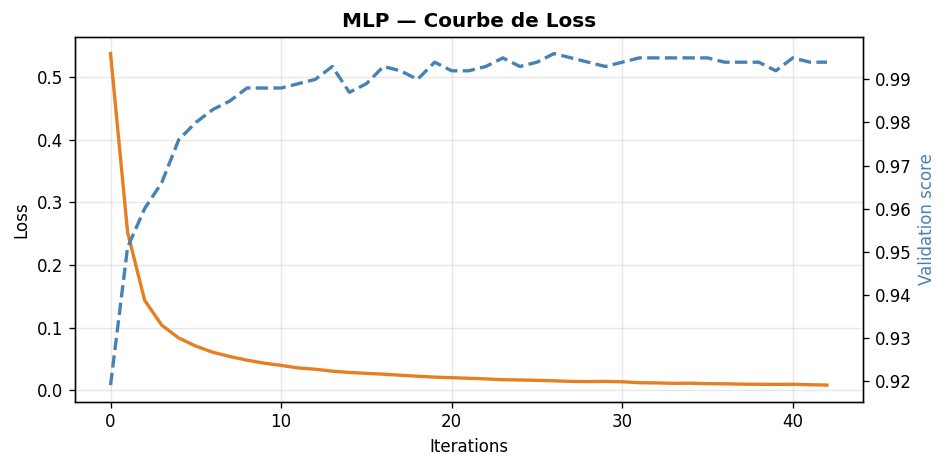

In [13]:
if hasattr(mlp, "loss_curve_") and mlp.loss_curve_:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(mlp.loss_curve_, color="#e67e22", linewidth=2, label="Train loss")
    if hasattr(mlp, "validation_scores_") and mlp.validation_scores_:
        ax2 = ax.twinx()
        ax2.plot(mlp.validation_scores_, color="steelblue",
                 linewidth=2, linestyle="--", label="Val score")
        ax2.set_ylabel("Validation score", color="steelblue")
    ax.set_title("MLP — Courbe de Loss", fontweight="bold")
    ax.set_xlabel("Iterations")
    ax.set_ylabel("Loss")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "mlp_loss.png"),
                dpi=150, bbox_inches="tight")
    plt.show()

---
## 12. Modele 4 — KNN (k=5)

In [14]:
t0 = time.time()
knn = KNeighborsClassifier(
    n_neighbors=5,
    weights="distance",
    metric="euclidean",
    n_jobs=-1
)
knn.fit(X_knn, y_knn)
y_pred_knn  = knn.predict(X_test_s)
proba_knn   = knn.predict_proba(X_test_s)
t_knn       = time.time() - t0

auc_knn = roc_auc_score(y_test, proba_knn[:, SURCHARGE_IDX])
print(f"Temps    : {t_knn:.1f}s")
print(f"Accuracy : {accuracy_score(y_test,y_pred_knn)*100:.2f}%")
print(f"F1 binar : {f1_score(y_test,y_pred_knn,average='binary',pos_label=SURCHARGE_IDX,zero_division=0)*100:.2f}%")
print(f"AUC-ROC  : {auc_knn:.4f}")
print()
print(classification_report(y_test,y_pred_knn,target_names=CLASS_NAMES,zero_division=0))

Temps    : 0.7s
Accuracy : 91.07%
F1 binar : 77.84%
AUC-ROC  : 0.9822

              precision    recall  f1-score   support

      Normal       1.00      0.90      0.94      8396
   Surcharge       0.65      0.98      0.78      1604

    accuracy                           0.91     10000
   macro avg       0.82      0.94      0.86     10000
weighted avg       0.94      0.91      0.92     10000



---
## 13. Modele 5 — SVM (RBF)

In [15]:
t0 = time.time()
svm = SVC(
    kernel="rbf",
    C=10.0,
    gamma="scale",
    class_weight="balanced",
    probability=True,
    random_state=42
)
svm.fit(X_svm, y_svm)
y_pred_svm  = svm.predict(X_test_s)
proba_svm   = svm.predict_proba(X_test_s)
t_svm       = time.time() - t0

auc_svm = roc_auc_score(y_test, proba_svm[:, SURCHARGE_IDX])
print(f"Temps    : {t_svm:.1f}s  (train : {len(y_svm):,} echantillons)")
print(f"Accuracy : {accuracy_score(y_test,y_pred_svm)*100:.2f}%")
print(f"F1 binar : {f1_score(y_test,y_pred_svm,average='binary',pos_label=SURCHARGE_IDX,zero_division=0)*100:.2f}%")
print(f"AUC-ROC  : {auc_svm:.4f}")
print()
print(classification_report(y_test,y_pred_svm,target_names=CLASS_NAMES,zero_division=0))

Temps    : 1.7s  (train : 6,000 echantillons)
Accuracy : 98.09%
F1 binar : 94.37%
AUC-ROC  : 0.9994

              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99      8396
   Surcharge       0.90      1.00      0.94      1604

    accuracy                           0.98     10000
   macro avg       0.95      0.99      0.97     10000
weighted avg       0.98      0.98      0.98     10000



---
## 14. Modele 6 — XGBoost

In [16]:
t0 = time.time()
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb.fit(X_train_s, y_train, sample_weight=sw_xgb)
y_pred_xgb  = xgb.predict(X_test_s)
proba_xgb   = xgb.predict_proba(X_test_s)
t_xgb       = time.time() - t0

auc_xgb = roc_auc_score(y_test, proba_xgb[:, SURCHARGE_IDX])
print(f"Temps    : {t_xgb:.1f}s")
print(f"Accuracy : {accuracy_score(y_test,y_pred_xgb)*100:.2f}%")
print(f"F1 binar : {f1_score(y_test,y_pred_xgb,average='binary',pos_label=SURCHARGE_IDX,zero_division=0)*100:.2f}%")
print(f"AUC-ROC  : {auc_xgb:.4f}")
print()
print(classification_report(y_test,y_pred_xgb,target_names=CLASS_NAMES,zero_division=0))

Temps    : 1.0s
Accuracy : 98.77%
F1 binar : 96.27%
AUC-ROC  : 0.9995

              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99      8396
   Surcharge       0.94      0.99      0.96      1604

    accuracy                           0.99     10000
   macro avg       0.97      0.99      0.98     10000
weighted avg       0.99      0.99      0.99     10000



---
## 15. Ensemble — Soft Voting (6 Modeles)

In [17]:
proba_ens  = (proba_rf + proba_hgb + proba_mlp +
              proba_knn + proba_svm + proba_xgb) / 6
y_pred_ens = np.argmax(proba_ens, axis=1)
auc_ens    = roc_auc_score(y_test, proba_ens[:, SURCHARGE_IDX])

print(f"Ensemble — Accuracy : {accuracy_score(y_test,y_pred_ens)*100:.2f}%")
print(f"Ensemble — F1 binar : {f1_score(y_test,y_pred_ens,average='binary',pos_label=SURCHARGE_IDX,zero_division=0)*100:.2f}%")
print(f"Ensemble — AUC-ROC  : {auc_ens:.4f}")
print()
print(classification_report(y_test,y_pred_ens,target_names=CLASS_NAMES,zero_division=0))

Ensemble — Accuracy : 98.86%
Ensemble — F1 binar : 96.56%
Ensemble — AUC-ROC  : 0.9998

              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99      8396
   Surcharge       0.94      1.00      0.97      1604

    accuracy                           0.99     10000
   macro avg       0.97      0.99      0.98     10000
weighted avg       0.99      0.99      0.99     10000



---
## 16. Matrices de Confusion — Tous les Modeles

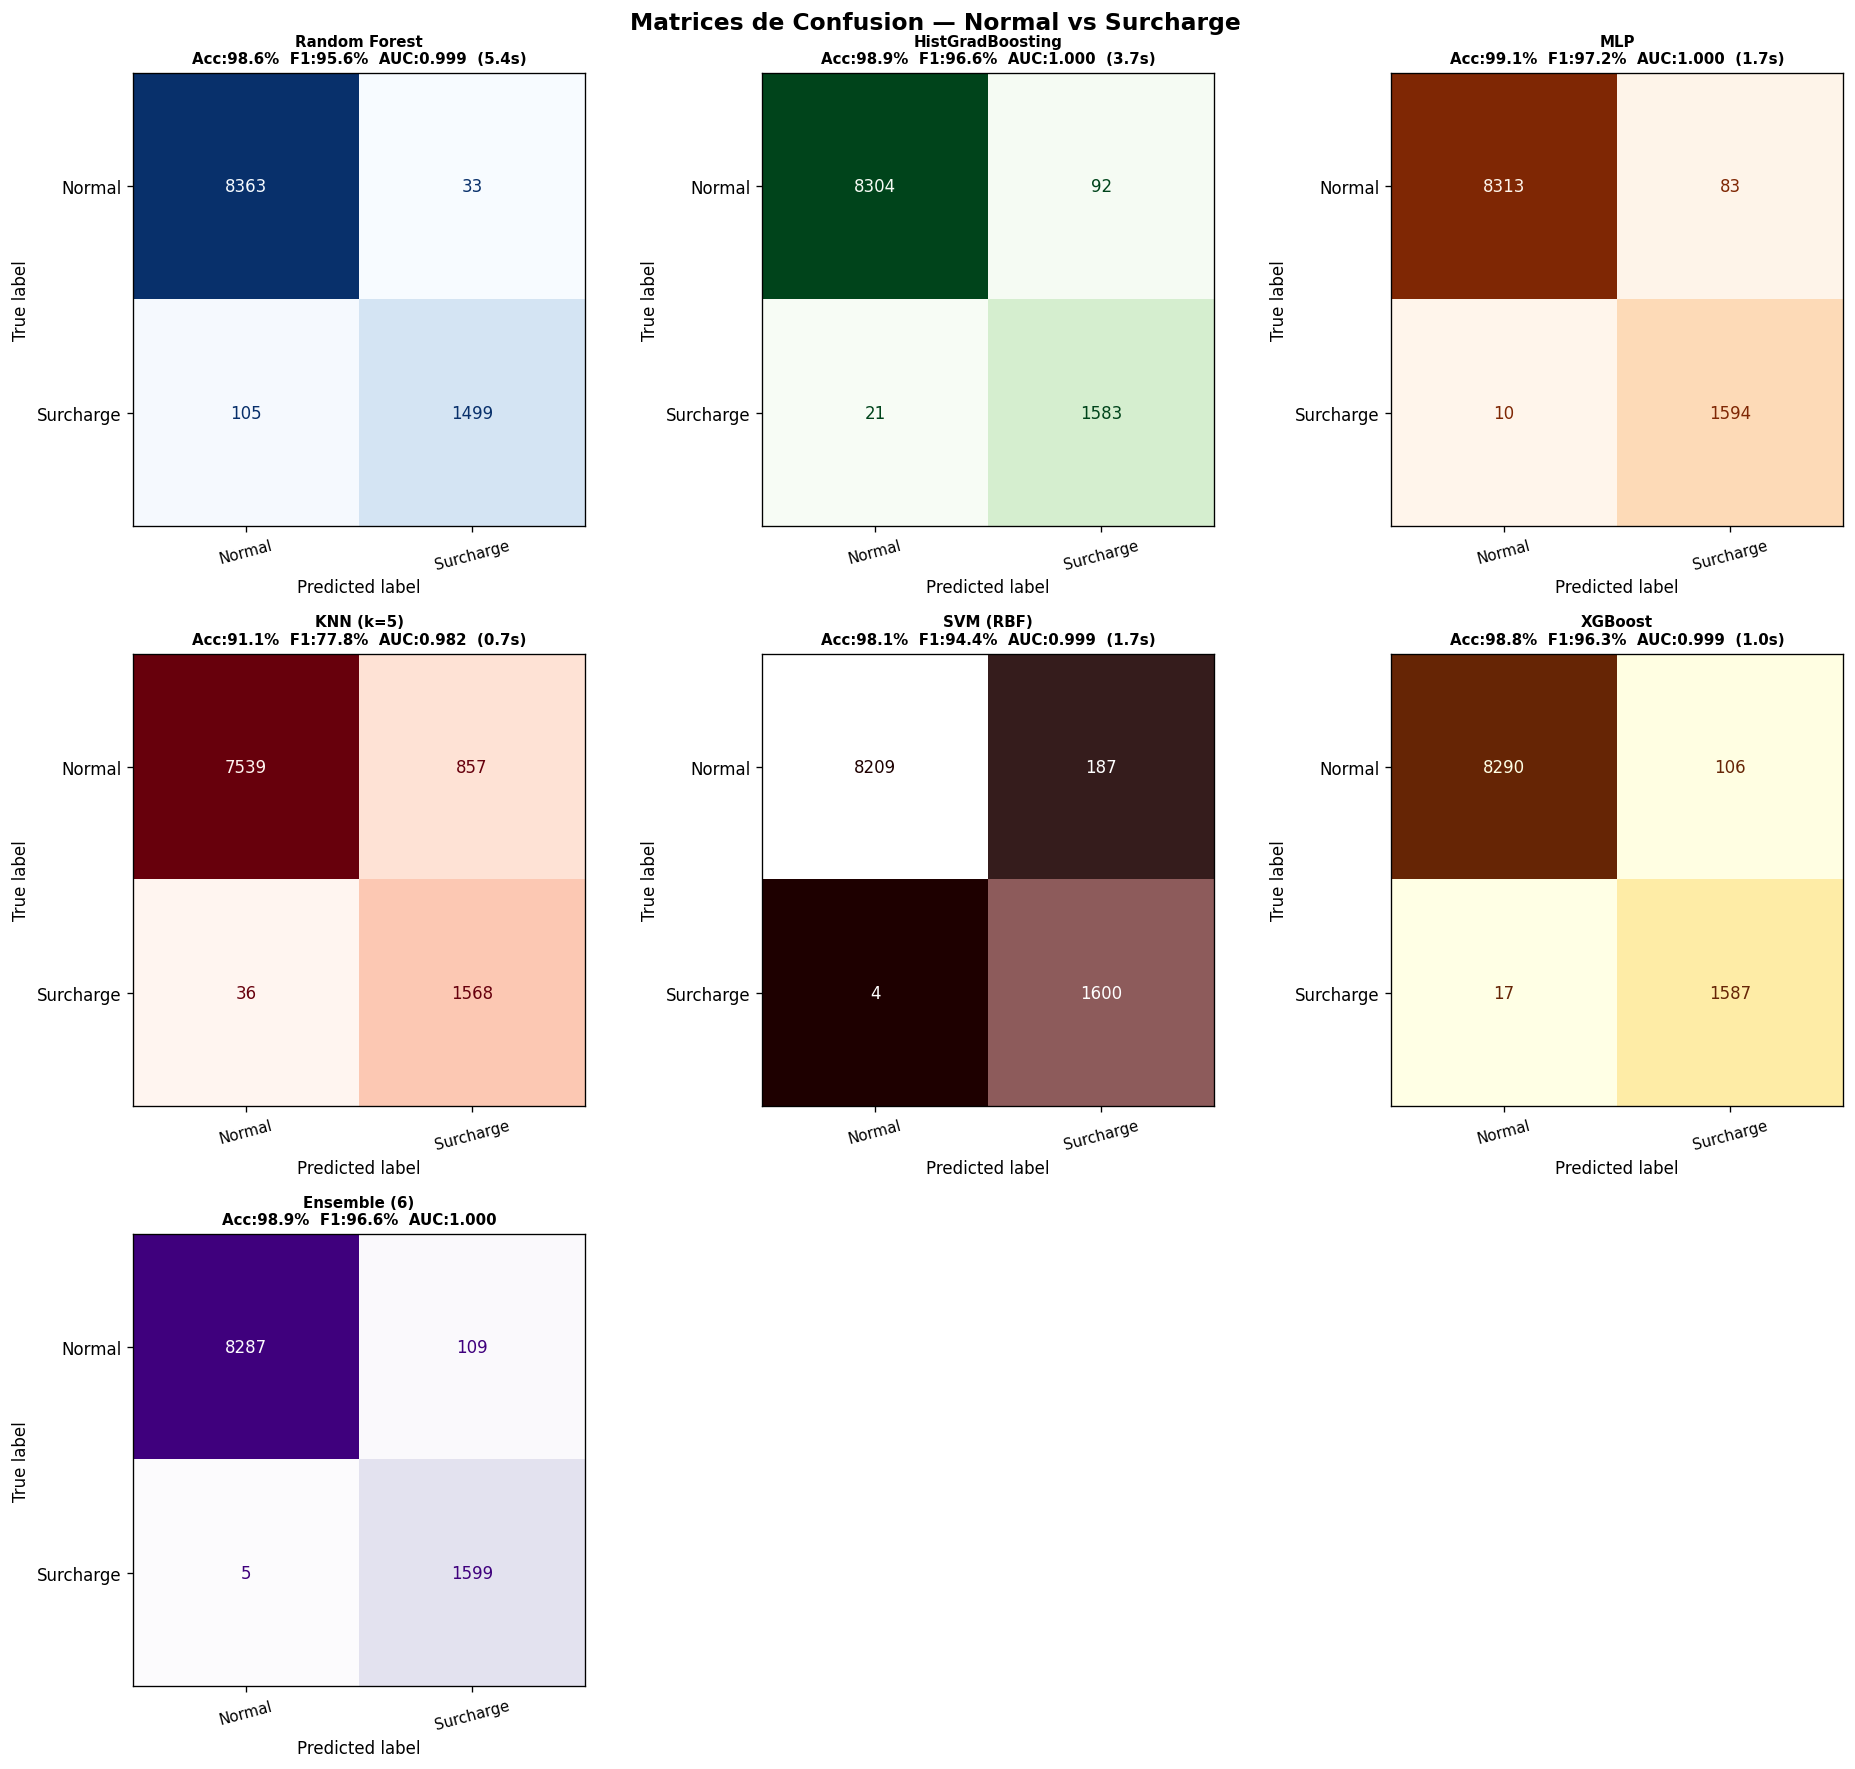

Figure sauvegardee : outputs_binary/confusion_matrices.png


In [18]:
all_models = [
    (y_pred_rf,  proba_rf,  "Random Forest",    "Blues",   t_rf),
    (y_pred_hgb, proba_hgb, "HistGradBoosting", "Greens",  t_hgb),
    (y_pred_mlp, proba_mlp, "MLP",              "Oranges", t_mlp),
    (y_pred_knn, proba_knn, "KNN (k=5)",        "Reds",    t_knn),
    (y_pred_svm, proba_svm, "SVM (RBF)",        "pink",    t_svm),
    (y_pred_xgb, proba_xgb, "XGBoost",          "YlOrBr",  t_xgb),
    (y_pred_ens, proba_ens, "Ensemble (6)",     "Purples", None),
]

fig, axes = plt.subplots(3, 3, figsize=(16, 15))
axes = axes.flatten()

for ax, (yp, pb, name, cmap, t) in zip(axes, all_models):
    cm  = confusion_matrix(y_test, yp)
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
        ax=ax, cmap=cmap, colorbar=False)
    acc = accuracy_score(y_test, yp)
    f1b = f1_score(y_test, yp, average="binary",
                   pos_label=SURCHARGE_IDX, zero_division=0)
    auc = roc_auc_score(y_test, pb[:, SURCHARGE_IDX])
    title = f"{name}\nAcc:{acc*100:.1f}%  F1:{f1b*100:.1f}%  AUC:{auc:.3f}"
    if t is not None:
        title += f"  ({t:.1f}s)"
    ax.set_title(title, fontweight="bold", fontsize=9)
    ax.tick_params(axis="x", rotation=15, labelsize=9)

for ax in axes[len(all_models):]:
    ax.set_visible(False)

plt.suptitle("Matrices de Confusion — Normal vs Surcharge",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrices.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/confusion_matrices.png")

---
## 17. Courbes ROC — Comparaison des Modeles

> La courbe ROC montre le compromis entre le taux de vrais positifs (detection de surcharge) et le taux de faux positifs (fausses alarmes) pour chaque seuil de probabilite.

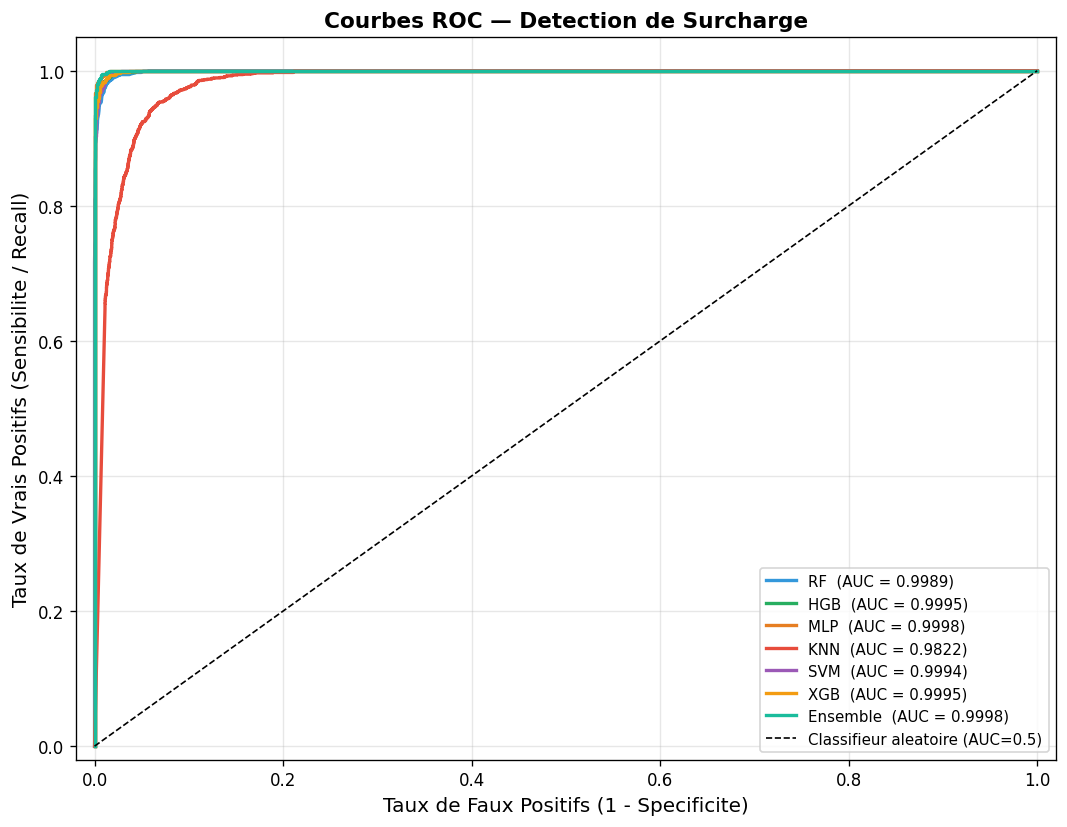

Figure sauvegardee : outputs_binary/roc_curves.png


In [19]:
algo_colors = ["#3498db","#27ae60","#e67e22","#e74c3c","#9b59b6","#f39c12","#1abc9c"]
algo_labels = ["RF","HGB","MLP","KNN","SVM","XGB","Ensemble"]
all_probas  = [proba_rf,proba_hgb,proba_mlp,proba_knn,proba_svm,proba_xgb,proba_ens]

fig, ax = plt.subplots(figsize=(9, 7))

for proba, name, col in zip(all_probas, algo_labels, algo_colors):
    fpr, tpr, _ = roc_curve(y_test, proba[:, SURCHARGE_IDX])
    auc         = roc_auc_score(y_test, proba[:, SURCHARGE_IDX])
    ax.plot(fpr, tpr, color=col, linewidth=2,
            label=f"{name}  (AUC = {auc:.4f})")

ax.plot([0,1],[0,1], "k--", linewidth=1, label="Classifieur aleatoire (AUC=0.5)")
ax.set_xlabel("Taux de Faux Positifs (1 - Specificite)", fontsize=12)
ax.set_ylabel("Taux de Vrais Positifs (Sensibilite / Recall)", fontsize=12)
ax.set_title("Courbes ROC — Detection de Surcharge",
             fontweight="bold", fontsize=13)
ax.legend(fontsize=9, loc="lower right")
ax.grid(alpha=0.3)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.05])

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "roc_curves.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/roc_curves.png")

---
## 18. Comparaison Globale

In [20]:
def get_metrics_bin(yt, yp, pb, name, t=None):
    d = {
        "Algorithme"     : name,
        "Accuracy (%)"   : round(accuracy_score(yt,yp)*100, 2),
        "F1 Surcharge (%)": round(f1_score(yt,yp,average="binary",
                                  pos_label=SURCHARGE_IDX,zero_division=0)*100, 2),
        "Precision (%)"  : round(precision_score(yt,yp,average="binary",
                                  pos_label=SURCHARGE_IDX,zero_division=0)*100, 2),
        "Recall (%)"     : round(recall_score(yt,yp,average="binary",
                                  pos_label=SURCHARGE_IDX,zero_division=0)*100, 2),
        "AUC-ROC"        : round(roc_auc_score(yt, pb[:,SURCHARGE_IDX]), 4),
    }
    if t is not None: d["Temps (s)"] = round(t, 1)
    return d

results = pd.DataFrame([
    get_metrics_bin(y_test, y_pred_rf,  proba_rf,  "Random Forest",    t_rf),
    get_metrics_bin(y_test, y_pred_hgb, proba_hgb, "HistGradBoosting", t_hgb),
    get_metrics_bin(y_test, y_pred_mlp, proba_mlp, "MLP",              t_mlp),
    get_metrics_bin(y_test, y_pred_knn, proba_knn, "KNN (k=5)",        t_knn),
    get_metrics_bin(y_test, y_pred_svm, proba_svm, "SVM (RBF)",        t_svm),
    get_metrics_bin(y_test, y_pred_xgb, proba_xgb, "XGBoost",          t_xgb),
    get_metrics_bin(y_test, y_pred_ens, proba_ens, "Ensemble (6)",     None),
]).set_index("Algorithme")

print("=" * 80)
print("          COMPARAISON — CLASSIFICATION BINAIRE : Normal vs Surcharge")
print("=" * 80)
print(results.to_string())
print("=" * 80)

best_f1  = results["F1 Surcharge (%)"].idxmax()
best_auc = results["AUC-ROC"].idxmax()
print(f"\nMeilleur F1 Surcharge : {best_f1}  =>  {results.loc[best_f1,'F1 Surcharge (%)']}%")
print(f"Meilleur AUC-ROC      : {best_auc}  =>  {results.loc[best_auc,'AUC-ROC']}")

          COMPARAISON — CLASSIFICATION BINAIRE : Normal vs Surcharge
                  Accuracy (%)  F1 Surcharge (%)  Precision (%)  Recall (%)  AUC-ROC  Temps (s)
Algorithme                                                                                     
Random Forest            98.62             95.60          97.85       93.45   0.9989        5.4
HistGradBoosting         98.87             96.55          94.51       98.69   0.9995        3.7
MLP                      99.07             97.17          95.05       99.38   0.9998        1.7
KNN (k=5)                91.07             77.84          64.66       97.76   0.9822        0.7
SVM (RBF)                98.09             94.37          89.54       99.75   0.9994        1.7
XGBoost                  98.77             96.27          93.74       98.94   0.9995        1.0
Ensemble (6)             98.86             96.56          93.62       99.69   0.9998        NaN

Meilleur F1 Surcharge : MLP  =>  97.17%
Meilleur AUC-ROC      : ML

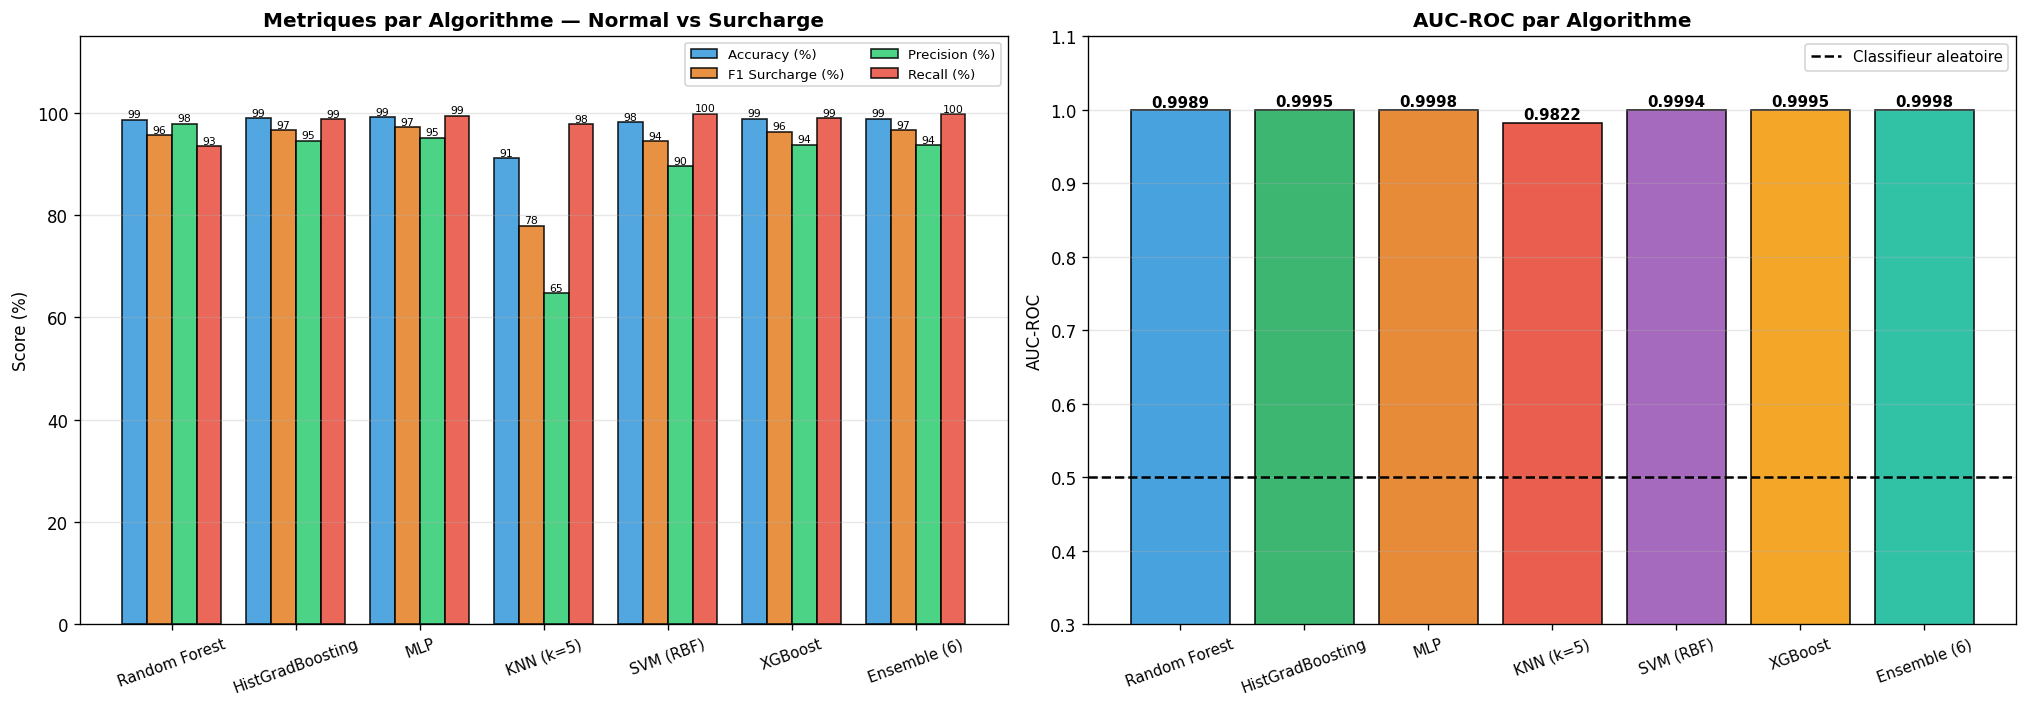

Figure sauvegardee : outputs_binary/comparison_binary.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

algo_colors = ["#3498db","#27ae60","#e67e22","#e74c3c","#9b59b6","#f39c12","#1abc9c"]
algo_labels = list(results.index)
x           = np.arange(len(results))
width       = 0.2

# Graphique 1 : 4 metriques
metrics_to_plot = ["Accuracy (%)", "F1 Surcharge (%)", "Precision (%)", "Recall (%)"]
metric_colors   = ["#3498db","#e67e22","#2ecc71","#e74c3c"]

for j, (met, col) in enumerate(zip(metrics_to_plot, metric_colors)):
    axes[0].bar(x + j*width - 1.5*width, results[met],
                width, label=met, color=col, edgecolor="black", alpha=0.85)

axes[0].set_title("Metriques par Algorithme — Normal vs Surcharge",
                  fontweight="bold", fontsize=12)
axes[0].set_ylabel("Score (%)")
axes[0].set_ylim(0, 115)
axes[0].set_xticks(x)
axes[0].set_xticklabels(algo_labels, rotation=20, fontsize=9)
axes[0].legend(fontsize=8, ncol=2)
axes[0].grid(axis="y", alpha=0.3)
for j, (met, col) in enumerate(zip(metrics_to_plot, metric_colors)):
    for i, val in enumerate(results[met]):
        axes[0].text(i + j*width - 1.5*width, val+0.5,
                     f"{val:.0f}", ha="center", fontsize=6.5)

# Graphique 2 : AUC-ROC
auc_vals = results["AUC-ROC"].values
bars = axes[1].bar(algo_labels, auc_vals,
                   color=algo_colors, edgecolor="black", alpha=0.9)
axes[1].axhline(0.5, color="black", linestyle="--",
                linewidth=1.5, label="Classifieur aleatoire")
axes[1].set_title("AUC-ROC par Algorithme",
                  fontweight="bold", fontsize=12)
axes[1].set_ylabel("AUC-ROC")
axes[1].set_ylim(0.3, 1.1)
axes[1].tick_params(axis="x", rotation=20, labelsize=9)
axes[1].legend(fontsize=9)
axes[1].grid(axis="y", alpha=0.3)
for bar, val in zip(bars, auc_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.005,
                 f"{val:.4f}", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "comparison_binary.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/comparison_binary.png")

---
## 19. Importance des Features

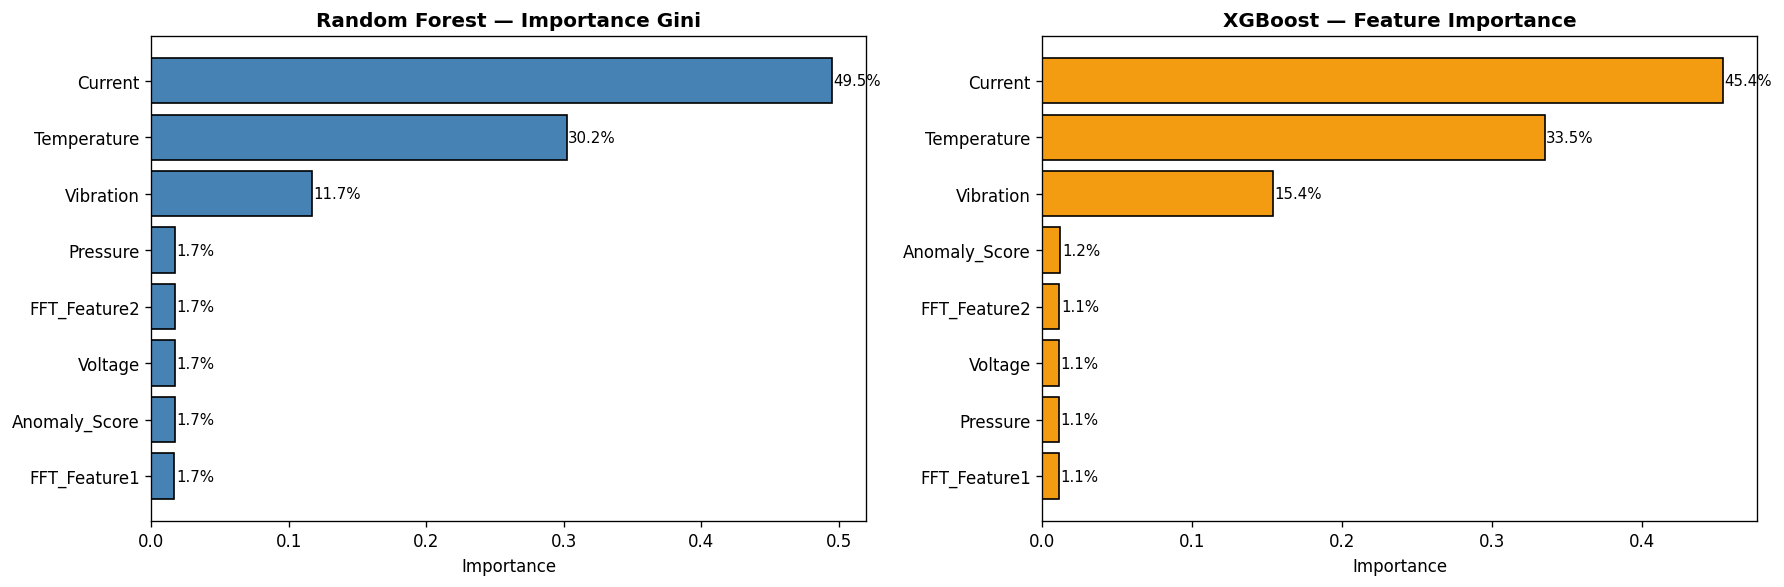

Figure sauvegardee : outputs_binary/feature_importance.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# RF
imp_rf    = rf.feature_importances_
sorted_rf = np.argsort(imp_rf)
axes[0].barh([FEATURE_COLS[i] for i in sorted_rf],
              imp_rf[sorted_rf], color="steelblue", edgecolor="black")
axes[0].set_title("Random Forest — Importance Gini",
                  fontweight="bold")
axes[0].set_xlabel("Importance")
for i, v in enumerate(imp_rf[sorted_rf]):
    axes[0].text(v+0.001, i, f"{v*100:.1f}%", va="center", fontsize=9)

# XGBoost
imp_xgb    = xgb.feature_importances_
sorted_xgb = np.argsort(imp_xgb)
axes[1].barh([FEATURE_COLS[i] for i in sorted_xgb],
              imp_xgb[sorted_xgb], color="#f39c12", edgecolor="black")
axes[1].set_title("XGBoost — Feature Importance",
                  fontweight="bold")
axes[1].set_xlabel("Importance")
for i, v in enumerate(imp_xgb[sorted_xgb]):
    axes[1].text(v+0.001, i, f"{v*100:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "feature_importance.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/feature_importance.png")

---
## 20. Sauvegarde des Modeles

In [23]:
to_save = {
    "rf_model.joblib"         : rf,
    "hgb_model.joblib"        : hgb,
    "mlp_model.joblib"        : mlp,
    "knn_model.joblib"        : knn,
    "svm_model.joblib"        : svm,
    "xgb_model.joblib"        : xgb,
    "scaler.joblib"           : scaler,
    "label_encoder.joblib"    : le,
    "feature_cols.joblib"     : FEATURE_COLS,
}
for fname, obj in to_save.items():
    joblib.dump(obj, os.path.join(OUTPUT_DIR, fname))

print(f"Modeles sauvegardes dans '{OUTPUT_DIR}/' :")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    if fname.endswith(".joblib"):
        sz = os.path.getsize(os.path.join(OUTPUT_DIR, fname))
        print(f"  {fname:<35} ({sz/1024:.1f} KB)")

Modeles sauvegardes dans 'outputs_binary/' :
  feature_cols.joblib                 (0.1 KB)
  hgb_model.joblib                    (724.3 KB)
  knn_model.joblib                    (1487.5 KB)
  label_encoder.joblib                (0.5 KB)
  mlp_model.joblib                    (71.9 KB)
  rf_model.joblib                     (58655.9 KB)
  scaler.joblib                       (0.8 KB)
  svm_model.joblib                    (38.5 KB)
  xgb_model.joblib                    (776.2 KB)


---
## 21. Prediction en Temps Reel

In [24]:
def predict_surcharge(
    temperature   = 50.0,
    vibration     = 80.0,
    pressure      = 200.0,
    voltage       = 220.0,
    current       = 10.0,
    fft1          = 0.5,
    fft2          = 0.5,
    anomaly_score = 0.3,
    use_ensemble  = True
):
    """
    Detecte si le moteur DC est en surcharge ou en etat normal.

    Parametres
    ----------
    temperature   : Temperature en C (nominal ~50)
    vibration     : Vibration (nominal ~100)
    pressure      : Pression (nominal ~200)
    voltage       : Tension en V (nominal ~220)
    current       : Courant en A (nominal ~10)
    fft1, fft2    : Caracteristiques spectrales [0..1]
    anomaly_score : Score d anomalie [0..1]
    use_ensemble  : True = moyenne 6 modeles (recommande)
    """
    # Verification par la formule physique
    z_I_val   = (current     - I_NOM)   / I_STD
    z_T_val   = (temperature - T_NOM)   / T_STD
    z_Vib_val = (vibration   - VIB_NOM) / VIB_STD
    ol_val    = W_CURRENT*z_I_val + W_TEMP*z_T_val + W_VIB*z_Vib_val
    expected  = "Surcharge" if ol_val > OL_THRESHOLD else "Normal"

    # Prediction ML
    sample   = np.array([[temperature, vibration, pressure, voltage, current,
                          fft1, fft2, anomaly_score]], dtype=float)
    sample   = np.nan_to_num(sample, nan=0.0, posinf=0.0, neginf=0.0)
    sample_s = scaler.transform(sample)

    if use_ensemble:
        proba = (rf.predict_proba(sample_s) +
                 hgb.predict_proba(sample_s) +
                 mlp.predict_proba(sample_s) +
                 knn.predict_proba(sample_s) +
                 svm.predict_proba(sample_s) +
                 xgb.predict_proba(sample_s)) / 6
        model_used = "Ensemble (6 modeles)"
    else:
        proba      = rf.predict_proba(sample_s)
        model_used = "Random Forest"

    pred_label = le.inverse_transform([np.argmax(proba)])[0]
    p_surcharge = proba[0, SURCHARGE_IDX] * 100
    p_normal    = proba[0, 1 - SURCHARGE_IDX] * 100

    print(f"  Capteurs    : T={temperature}C | Vib={vibration} | P={pressure}")
    print(f"                V={voltage}V | I={current}A | Anomaly={anomaly_score}")
    print(f"  ol_score    : {ol_val:.4f}  (seuil = {OL_THRESHOLD})")
    print(f"  Attendu     : {expected}")
    print(f"  Modele      : {model_used}")
    print(f"  Prediction  : {pred_label}")
    print(f"  P(Normal)   : {p_normal:.1f}%")
    print(f"  P(Surcharge): {p_surcharge:.1f}%")
    status = "OK" if pred_label == expected else "ECART"
    print(f"  Coherence   : {status}")
    return pred_label

print("predict_surcharge() prete.")

predict_surcharge() prete.


In [25]:
print("=" * 65)

print("\nTEST 1 — Fonctionnement Normal")
print("-" * 65)
predict_surcharge(temperature=50, vibration=80, pressure=200,
                  voltage=220, current=10, anomaly_score=0.3)

print("\nTEST 2 — Surcharge legere (courant eleve)")
print("-" * 65)
predict_surcharge(temperature=65, vibration=110, pressure=215,
                  voltage=218, current=14, anomaly_score=0.5)

print("\nTEST 3 — Surcharge moderee (courant + temperature)")
print("-" * 65)
predict_surcharge(temperature=78, vibration=130, pressure=230,
                  voltage=217, current=16, anomaly_score=0.7)

print("\nTEST 4 — Surcharge severe")
print("-" * 65)
predict_surcharge(temperature=92, vibration=155, pressure=250,
                  voltage=215, current=19, anomaly_score=0.88)

print("=" * 65)


TEST 1 — Fonctionnement Normal
-----------------------------------------------------------------
  Capteurs    : T=50C | Vib=80 | P=200
                V=220V | I=10A | Anomaly=0.3
  ol_score    : -0.1600  (seuil = 0.6)
  Attendu     : Normal
  Modele      : Ensemble (6 modeles)
  Prediction  : Normal
  P(Normal)   : 99.9%
  P(Surcharge): 0.1%
  Coherence   : OK

TEST 2 — Surcharge legere (courant eleve)
-----------------------------------------------------------------
  Capteurs    : T=65C | Vib=110 | P=215
                V=218V | I=14A | Anomaly=0.5
  ol_score    : 1.0300  (seuil = 0.6)
  Attendu     : Surcharge
  Modele      : Ensemble (6 modeles)
  Prediction  : Surcharge
  P(Normal)   : 0.2%
  P(Surcharge): 99.8%
  Coherence   : OK

TEST 3 — Surcharge moderee (courant + temperature)
-----------------------------------------------------------------
  Capteurs    : T=78C | Vib=130 | P=230
                V=217V | I=16A | Anomaly=0.7
  ol_score    : 1.7933  (seuil = 0.6)
  Attendu 

---
## Recapitulatif

### Pipeline

```
CSV (50 000 lignes)
    |
    v
Score de Surcharge (formule physique)
    z_I   = (I - 10) / 3
    z_T   = (T - 50) / 15
    z_Vib = (Vib - 100) / 25

    ol_score = 0.45*z_I + 0.35*z_T + 0.20*z_Vib

    Surcharge si ol_score > 0.6
    Normal    sinon
    |
    v
8 features physiques (Temperature, Vibration, Pressure,
                       Voltage, Current, FFT1, FFT2, Anomaly_Score)
    |
    v
Split 80/20 stratifie + StandardScaler
    |
    +---> RF   class_weight='balanced'     (40k)
    +---> HGB  class_weight='balanced'     (40k)
    +---> MLP  undersample equilibre       (10k)
    +---> KNN  undersample equilibre       (10k)
    +---> SVM  undersample equilibre       ( 6k)
    +---> XGB  sample_weight              (40k)
    +---> Ensemble Soft Voting (6 modeles)
              |
              v
         Accuracy | F1 Surcharge | Precision | Recall | AUC-ROC
         Confusion Matrices | Courbes ROC | Feature Importance
              |
              v
         Sauvegarde outputs_binary/*.joblib
```

### Metrique principale : AUC-ROC

Pour un diagnostic industriel, le **Recall de la classe Surcharge** est
critique : il vaut mieux avoir une fausse alarme (faux positif = Normal
classe comme Surcharge) qu'une surcharge non detectee (faux negatif).
La courbe ROC permet de choisir le seuil optimal selon le contexte.

---
*Projet de Fin d'Annee II — Diagnostic de Moteurs DC 12V par IA*